# PBCNet2.0 Prediction Pipeline for proQ Dataset
This notebook is configured for GPU execution and subset processing (10 ligands).

In [2]:
import os
import pandas as pd
import numpy as np
import pickle
import warnings
import torch
import dgl
from rdkit import Chem
from rdkit.Chem import AllChem, BRICS
from rdkit.Chem.rdchem import BondType as BT
from scipy.spatial import distance_matrix
from Bio.PDB import *
from Bio.PDB.PDBIO import Select
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')

# Smart path discovery
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, 'proQ')):
    dir_ = os.path.abspath('proQ')
    code_path = os.path.dirname(cwd)
else:
    dir_ = os.path.abspath(os.path.join('case', 'proQ'))
    code_path = cwd

ligand_dir = os.path.join(dir_, 'ligands')
print(f'Project root: {code_path}')
print(f'Data dir: {dir_}')

# GPU Diagnostics
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Found GPU: {torch.cuda.get_device_name(0)}')
else:
    print('GPU NOT FOUND. Running on CPU instead.')

Project root: d:\PBCNet2.0
Data dir: d:\PBCNet2.0\case\proQ
CUDA available: True
Found GPU: NVIDIA GeForce RTX 3050 Laptop GPU


### 1. Pocket Extraction Logic

In [3]:
def extract(ligand, pdb_path):
    if not ligand:
        return False
    parser = PDBParser(PERMISSIVE=1)
    structure = parser.get_structure("protein", pdb_path)
    
    lp = []
    for l in ligand:
        try:
            lp.append(l.GetConformer().GetPositions())
        except:
            continue
    
    if not lp:
        return False
        
    ligand_positions = np.concatenate(lp)

    class ResidueSelect(Select):
        def accept_residue(self, residue):
            residue_positions = np.array([np.array(list(atom.get_vector())) for atom in residue.get_atoms() if "H" not in atom.get_id()])
            if len(residue_positions.shape) < 2: return 0
            min_dis = np.min(distance_matrix(residue_positions, ligand_positions))
            return 1 if min_dis < 8.0 else 0

    io = PDBIO()
    io.set_structure(structure)
    pocket_path = pdb_path.replace('protein.pdb', 'pocket.pdb')
    io.save(pocket_path, ResidueSelect())
    return True

def pocket_extract(sdf_files, protein_file):
    ligands = []
    for a in sdf_files:
        mol = Chem.MolFromMolFile(a)
        if mol: ligands.append(mol)
    
    if extract(ligands, protein_file):
        print("Pocket extracted successfully.")
    else:
        print(f"Skipping: No valid conformers found in {sdf_files}")

In [3]:
ligand_dir = os.path.join(dir_, 'ligands')
protein_file = os.path.join(dir_, 'protein.pdb')
sdfs = [os.path.join(ligand_dir, i) for i in os.listdir(ligand_dir) if i.endswith('.sdf')]
# This 'sdfs' list will now contain ALL files in the folder.
for sdf in sdfs:
    pocket_extract([sdf], protein_file)


Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket e

[21:15:37] WARNING: not removing hydrogen atom without neighbors
[21:15:37] WARNING: not removing hydrogen atom without neighbors


Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket e

[21:15:43] Cannot convert '-2.' to unsigned int on line 4
[21:15:43] Cannot convert '-2.' to unsigned int on line 4


Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket e

### 2. Graph Generation Logic

In [4]:
allowable_features = {
    'possible_chirality_list': ['CHI_UNSPECIFIED', 'CHI_TETRAHEDRAL_CW', 'CHI_TETRAHEDRAL_CCW', 'CHI_OTHER'],
    'possible_degree_list': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'misc'],
    'possible_numring_list': [0, 1, 2, 3, 4, 5, 6, 'misc'],
    'possible_implicit_valence_list': [0, 1, 2, 3, 4, 5, 6, 'misc'],
    'possible_formal_charge_list': [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 'misc'],
    'possible_numH_list': [0, 1, 2, 3, 4, 5, 6, 7, 8, 'misc'],
    'possible_number_radical_e_list': [0, 1, 2, 3, 4, 'misc'],
    'possible_hybridization_list': ['SP', 'SP2', 'SP3', 'SP3D', 'SP3D2', 'misc'],
    'possible_is_aromatic_list': [False, True],
    'possible_is_in_ring3_list': [False, True],
    'possible_is_in_ring4_list': [False, True],
    'possible_is_in_ring5_list': [False, True],
    'possible_is_in_ring6_list': [False, True],
    'possible_is_in_ring7_list': [False, True],
    'possible_is_in_ring8_list': [False, True]
}
three_to_one = {'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R', 'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y', 'SEC': 'C', 'MSE': 'M'}
pro_res_table = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y', 'X']
pro_res_aliphatic_table = ['A', 'I', 'L', 'M', 'V']; pro_res_aromatic_table = ['F', 'W', 'Y']; pro_res_polar_neutral_table = ['C', 'N', 'Q', 'S', 'T']; pro_res_acidic_charged_table = ['D', 'E']; pro_res_basic_charged_table = ['H', 'K', 'R']
bonds = {BT.SINGLE: 0, BT.DOUBLE: 1, BT.TRIPLE: 2, BT.AROMATIC: 3}

def safe_index(l, e): 
    try: return l.index(e)
    except: return len(l)-1

def prop(residue):
    return [1 if residue in pro_res_aliphatic_table else 0, 1 if residue in pro_res_aromatic_table else 0, 1 if residue in pro_res_polar_neutral_table else 0, 1 if residue in pro_res_acidic_charged_table else 0, 1 if residue in pro_res_basic_charged_table else 0, 1]

def res_pocket(p):
    parser = PDBParser(PERMISSIVE=1)
    s = parser.get_structure('a', p)
    atom2res_idx, res_name, count = [], [], -1
    for model in s:
        for chain in model: 
            for residue in chain:
                count += 1; name = residue.get_resname()
                for atom in residue: 
                    if atom.get_fullname()[0] != 'H' and atom.get_fullname()[1] != 'H':
                        atom2res_idx.append(count); res_name.append(name)
    res3 = [three_to_one[i] if i in three_to_one.keys() else 'X' for i in res_name]
    return atom2res_idx, [pro_res_table.index(i) for i in res3], [prop(i) for i in res3]

def lig_atom_featurizer(mol):
    ringinfo = mol.GetRingInfo()
    return [[safe_index(allowable_features['possible_chirality_list'], str(atom.GetChiralTag())), safe_index(allowable_features['possible_degree_list'], atom.GetTotalDegree()), safe_index(allowable_features['possible_formal_charge_list'], atom.GetFormalCharge()), safe_index(allowable_features['possible_numH_list'], atom.GetTotalNumHs()), safe_index(allowable_features['possible_hybridization_list'], str(atom.GetHybridization())), allowable_features['possible_is_aromatic_list'].index(atom.GetIsAromatic()), safe_index(allowable_features['possible_implicit_valence_list'], atom.GetImplicitValence()), safe_index(allowable_features['possible_number_radical_e_list'], atom.GetNumRadicalElectrons()), safe_index(allowable_features['possible_numring_list'], ringinfo.NumAtomRings(idx))] for idx, atom in enumerate(mol.GetAtoms())]

def brics_decomp(mol):
    n_atoms = mol.GetNumAtoms()
    if n_atoms == 1: return [[0]]
    cliques = [[b.GetBeginAtomIdx(), b.GetEndAtomIdx()] for b in mol.GetBonds()]
    res = list(BRICS.FindBRICSBonds(mol))
    if len(res) == 0: return [list(range(n_atoms))]
    for bond in res:
        if [bond[0][0], bond[0][1]] in cliques: cliques.remove([bond[0][0], bond[0][1]])
        else: cliques.remove([bond[0][1], bond[0][0]])
        cliques.append([bond[0][0]]); cliques.append([bond[0][1]])
    for c in range(len(cliques) - 1):
        for k in range(c + 1, len(cliques)):
            if set(cliques[c]) & set(cliques[k]):
                cliques[c] = list(set(cliques[c]) | set(cliques[k])); cliques[k] = []
    return [c for c in cliques if c]

def group_complex(ligand, pocket_dir):
    brics_index = brics_decomp(ligand)
    group_index = [0 for _ in range(len(ligand.GetAtoms()))]
    group_type = [0 for _ in range(len(ligand.GetAtoms()))]
    group_prop = [[0,0,0,0,0,0] for _ in range(len(ligand.GetAtoms()))]
    for i, idx in enumerate(brics_index):
        for idx_ in idx: group_index[idx_] = i
    atom2res_idx, res_type, res_prop = res_pocket(pocket_dir)
    group_index.extend([i+len(brics_index) for i in atom2res_idx])
    group_type.extend([i+1 for i in res_type])
    group_prop.extend(res_prop)
    return torch.tensor(group_index, dtype=torch.float32), torch.tensor(group_type, dtype=torch.float32), torch.tensor(group_prop, dtype=torch.float32)

def bond_featurizer(ligand, pocket, index):
    bond_type = []; num_atoms = len(ligand.GetAtoms())
    for a1, a2 in zip(index[0].tolist(), index[1].tolist()):
        if a1 < num_atoms and a2 < num_atoms: bond = ligand.GetBondBetweenAtoms(int(a1), int(a2)); bond_type.append(bonds[bond.GetBondType()] if bond else 4)
        elif a1 >= num_atoms and a2 >= num_atoms: bond = pocket.GetBondBetweenAtoms(int(a1-num_atoms), int(a2-num_atoms)); bond_type.append(bonds[bond.GetBondType()] if bond else 4)
        else: bond_type.append(4)
    return torch.tensor(bond_type, dtype=torch.float32)

def Graph_Information(ligand_file, pocket_file):
    ligand = Chem.RemoveAllHs(Chem.MolFromMolFile(ligand_file))
    pocket = Chem.RemoveAllHs(Chem.MolFromPDBFile(pocket_file))
    if not pocket or not ligand: raise ValueError("Could not load pocket or ligand. Check file sanity.")
    G = dgl.heterograph({('atom', 'int', 'atom'): ([], []), ('atom', 'ind', 'atom'): ([], [])})
    l_at, p_at = np.array([i.GetAtomicNum() for i in ligand.GetAtoms()]), np.array([i.GetAtomicNum() for i in pocket.GetAtoms()])
    graph_x = torch.tensor(np.concatenate([l_at, p_at]))
    G.add_nodes(len(l_at) + len(p_at))
    coor_l, coor_p = ligand.GetConformer().GetPositions(), pocket.GetConformer().GetPositions()
    pos = torch.tensor(np.concatenate([coor_l, coor_p]), dtype=torch.float32)
    for i in range(len(coor_l)):
        for j in range(i + 1, len(coor_l)):
            if 0 < np.linalg.norm(coor_l[i] - coor_l[j]) <= 5: G.add_edges([i, j], [j, i], etype='int')
    for b in pocket.GetBonds():
        u, v = b.GetBeginAtomIdx() + len(coor_l), b.GetEndAtomIdx() + len(coor_l); G.add_edges([u, v], [v, u], etype='int')
    for i in range(len(coor_l)):
        for j in range(len(coor_p)):
            if 0 < np.linalg.norm(coor_l[i] - coor_p[j]) <= 5: G.add_edges([i, len(coor_l) + j], [len(coor_l) + j, i], etype='int')
    conn_p = set(int(j) for i in range(len(coor_l)) for j in G.successors(i, etype='int') if j >= len(coor_l))
    for i in conn_p:
        for j in range(len(coor_p)):
            if i != len(coor_l)+j and 0 < np.linalg.norm(coor_p[i-len(coor_l)] - coor_p[j]) <= 3 and not G.has_edges_between(i, len(coor_l)+j, etype='int'): G.add_edges([i, len(coor_l)+j], [len(coor_l)+j, i], etype='int')
    index, g_type, g_prop = group_complex(ligand, pocket_file)
    G.nodes['atom'].data.update({'x': graph_x, 'pos': pos, 'type': torch.tensor(np.concatenate([[1]*len(l_at), [0]*len(p_at)])), 'atom_scalar': torch.tensor(np.concatenate([lig_atom_featurizer(ligand), lig_atom_featurizer(pocket)]), dtype=torch.float32), 'res_idx': index, 'res_type': g_type, 'res_prop': g_prop})
    G.edges['int'].data['bond_scalar'] = bond_featurizer(ligand, pocket, G.edges(etype='int'))
    G.edges['ind'].data['bond_scalar'] = bond_featurizer(ligand, pocket, G.edges(etype='ind'))
    return G


In [5]:
def graph_save(lig_f, pock_f, save_f):
    if not os.path.exists(lig_f) or not os.path.exists(pock_f): return
    try:
        # Use a temp file and rename it to avoid 0-byte corruption if interrupted
        temp_f = save_f + '.tmp'
        with open(temp_f, 'wb') as f: 
            pickle.dump(Graph_Information(lig_f, pock_f), f)
        os.replace(temp_f, save_f)
    except Exception as e:
        if os.path.exists(save_f + '.tmp'): os.remove(save_f + '.tmp')
        print(f"Error with {os.path.basename(lig_f)}: {e}")

In [ ]:
import multiprocessing
from functools import partial

# 1. Paths
pocket_f = os.path.join(dir_, 'pocket.pdb')
pickle_dir = os.path.join(dir_, 'pickles')
os.makedirs(pickle_dir, exist_ok=True)

# 2. Helper function for parallel processing
def parallel_graph_save(sdf_name, ligand_dir, pocket_f, pickle_dir):
    lig_f = os.path.join(ligand_dir, sdf_name)
    save_f = os.path.join(pickle_dir, sdf_name.replace('.sdf', '.pkl'))
    
    # Only generate if it doesn't exist or is empty
    if not os.path.exists(save_f) or os.path.getsize(save_f) == 0:
        graph_save(lig_f, pocket_f, save_f)

# 3. Execution
sdfs = [i for i in os.listdir(ligand_dir) if i.endswith('.sdf')]
print(f"Starting Parallel Graph Generation for {len(sdfs)} ligands...")

pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())
func = partial(parallel_graph_save, ligand_dir=ligand_dir, pocket_f=pocket_f, pickle_dir=pickle_dir)

# Run in parallel and show progress
for i, _ in enumerate(pool.imap_unordered(func, sdfs), 1):
    if i % 100 == 0: 
        print(f"Processed {i}/{len(sdfs)} graphs...")

pool.close()
pool.join()
print("All Graphs Generated Successfully!")


Starting Parallel Graph Generation for 2856 ligands...


### 3. CSV Input Preparation

In [ ]:
import pandas as pd
import numpy as np
import os

def create_prediction_csv(pickle_dir, csv_save_path):
    # 1. Get all pickle files from the CORRECT folder
    pkls = sorted([os.path.join(pickle_dir, i) for i in os.listdir(pickle_dir) if i.endswith('.pkl')])
    
    if not pkls:
        print(f"Error: No .pkl files found in {pickle_dir}")
        return

    # 2. We compare every ligand to the first one (ligand_0) to get a relative rank
    ref_pkl = pkls[0]
    ref_name = os.path.basename(ref_pkl)
    
    data = {
        'lig1': [ref_name] * len(pkls),
        'lig2': [os.path.basename(p) for p in pkls],
        'Label': [0.0] * len(pkls),
        'Label1': [0.0] * len(pkls),
        'Label2': [0.0] * len(pkls),
        'dir_1': [ref_pkl] * len(pkls),
        'dir_2': pkls
    }
    
    df = pd.DataFrame(data)
    df.to_csv(csv_save_path, index=False)
    print(f"✅ predict.csv created successfully!")
    print(f"   Total ligands found: {len(pkls)}")
    print(f"   Saved to: {csv_save_path}")

# Run it
pickle_dir = os.path.join(dir_, 'pickles')
csv_path = os.path.join(dir_, 'predict.csv')
create_prediction_csv(pickle_dir, csv_path)


✅ predict.csv created successfully!
   Total ligands found: 2850
   Saved to: d:\PBCNet2.0\case\proQ\predict.csv


### 4. Model Prediction (GPU)

In [13]:
import sys
sys.path.append(os.path.join(code_path, 'model_code'))
from Dataloader.dataloader import LeadOptDataset, collate_fn
from predict.predict import predict as model_predict

def test_gpu(model, device, csv_path, batch_size):
    model.to(device)
    dataset = LeadOptDataset(csv_path)
    loader = DataLoader(dataset, collate_fn=collate_fn, batch_size=batch_size, shuffle=False)
    *_, valid_prediction, _, _, _, _ = model_predict(model, loader, device)
    return valid_prediction

model_file = os.path.join(code_path, 'PBCNet2.pth')
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Prediction running on: {device}')

model = torch.load(model_file, map_location=torch.device(device), weights_only=False)

csv_path = os.path.join(dir_, 'predict.csv')
pre = test_gpu(model, device, csv_path, 8)

df = pd.read_csv(csv_path)
df['pre'] = pre
df.to_csv(csv_path, index=0)
print("Prediction complete. Results saved in predict.csv")

Prediction running on: cuda:0
Prediction complete. Results saved in predict.csv


### 5. Final Results View

In [16]:
pd.read_csv(os.path.join(dir_, 'predict.csv')).head(2851)

,lig1,lig2,Label,Label1,Label2,dir_1,dir_2,pre
0,ligand_0.pkl,ligand_0.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,-0.079732
1,ligand_0.pkl,ligand_1.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_1.pkl,0.867108
2,ligand_0.pkl,ligand_10.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_10.pkl,0.903001
3,ligand_0.pkl,ligand_100.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_100.pkl,0.917175
4,ligand_0.pkl,ligand_1000.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_1000.pkl,0.884851
...,...,...,...,...,...,...,...,...
2845,ligand_0.pkl,ligand_995.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_995.pkl,0.903817
2846,ligand_0.pkl,ligand_996.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_996.pkl,0.948532
2847,ligand_0.pkl,ligand_997.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_997.pkl,0.818396
2848,ligand_0.pkl,ligand_998.pkl,0.0,0.0,0.0,d:\PBCNet2.0\case\proQ\pickles\ligand_0.pkl,d:\PBCNet2.0\case\proQ\pickles\ligand_998.pkl,0.976205


### 6. Visualization and Metrics

In [17]:
import scipy.stats as stats
from sklearn.metrics import mean_squared_error

def S(X, Y): return stats.spearmanr(X, Y)[0]
def R(X, Y): return stats.pearsonr(X, Y)[0]
def RMSE(X, Y): return mean_squared_error(X, Y) ** 0.5

csv_path = os.path.join(dir_, 'predict.csv')
df = pd.read_csv(csv_path)

print(f"Spearman correlation: {S(df['Label1'], df['pre']):.4f}")
print(f"Pearson correlation: {R(df['Label1'], df['pre']):.4f}")
print(f"RMSE: {RMSE(df['Label1'], df['pre']):.4f}")

Spearman correlation: nan
Pearson correlation: nan
RMSE: 0.9193


Note: Skipping regression line because all experimental values are 0.0


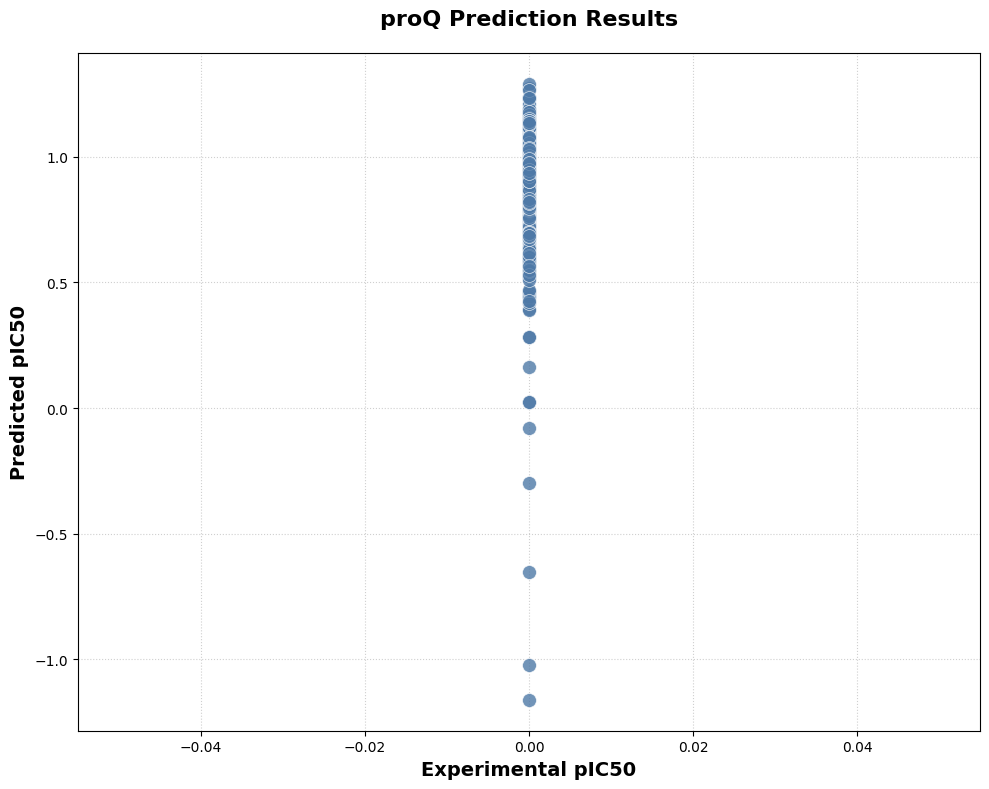

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plt_scatter(x, y, title='proQ Prediction Results'):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    # Draw the points
    axs.scatter(x, y, alpha=0.8, s=100, c="#4E79A7", edgecolors='white', linewidth=0.5, zorder=2)
    
    # --- FIX: Only try to fit a line if we have different x values ---
    if len(np.unique(x)) > 1:
        parameter = np.polyfit(x, y, 1)
        y_pred = parameter[0] * np.array(x) + parameter[1]
        axs.plot(x, y_pred, ls="--", linewidth=2, alpha=0.7, c='#E15759', label=f'Fit (slope={parameter[0]:.2f})')
        axs.legend()
    else:
        print("Note: Skipping regression line because all experimental values are 0.0")

    axs.set_ylabel("Predicted pIC50", fontsize=14, fontweight='bold')
    axs.set_xlabel("Experimental pIC50", fontsize=14, fontweight='bold')
    axs.set_title(title, fontsize=16, fontweight='bold', pad=20)
    axs.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run the fixed function
plt_scatter(df['Label1'], df['pre'])


In [19]:
import pandas as pd

def get_top_ligands(csv_path, top_n=10):
    # Load the results
    df = pd.read_csv(csv_path)
    
    # Calculate the average 'pre' for each ligand (in case it was compared multiple times)
    # We group by 'lig2' because that is the ligand being predicted relative to the reference
    top_df = df.groupby('lig2')['pre'].mean().sort_values(ascending=False).reset_index()
    
    print(f"--- Top {top_n} Strongest Ligands ---")
    print(top_df.head(top_n))
    
    return top_df.head(top_n)

# Use the function on your predict.csv
top_10 = get_top_ligands(os.path.join(dir_, 'predict.csv'))


--- Top 10 Strongest Ligands ---
              lig2       pre
0  ligand_2173.pkl  1.291587
1  ligand_1741.pkl  1.274085
2   ligand_439.pkl  1.267015
3  ligand_2531.pkl  1.237470
4   ligand_972.pkl  1.233388
5  ligand_1446.pkl  1.231289
6  ligand_1690.pkl  1.211243
7  ligand_1290.pkl  1.189664
8  ligand_1751.pkl  1.189383
9  ligand_1624.pkl  1.180112
